## 1) Setup

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')

# Fixed seed for reproducibility
SEED = 42

## 2) Load Data and Select Features

We use only the 10 features identified in the EDA notebook.  
Keeping the feature set small and explainable .

In [18]:
ames = fetch_openml(name='house_prices', as_frame=True, parser='auto')
df = ames.frame.copy()
df['SalePrice'] = pd.to_numeric(df['SalePrice'], errors='coerce')

print(f'Full dataset shape: {df.shape}')

Full dataset shape: (1460, 81)


In [19]:
# The 10 features we selected in the EDA notebook
NUMERIC_FEATURES = [
    'GrLivArea',     # above grade living area sqft
    'GarageCars',    # garage size in car capacity
    'TotalBsmtSF',   # total basement sqft
    'YearBuilt',     # year the house was built
    'FullBath',      # full bathrooms above grade
    'BedroomAbvGr',  # bedrooms above grade
    'LotArea',       # lot size in sqft
]

ORDINAL_FEATURES = [
    'OverallQual',   # overall material and finish quality (1-10)
    'OverallCond',   # overall condition rating (1-10)
]

NOMINAL_FEATURES = [
    'Neighborhood',  # physical location within Ames city limits
]

ALL_FEATURES = NUMERIC_FEATURES + ORDINAL_FEATURES + NOMINAL_FEATURES
TARGET = 'SalePrice'

# Keep only what we need
df = df[ALL_FEATURES + [TARGET]].copy()

print(f'Working dataset shape: {df.shape}')
print(f'Nulls in selected features: {df.isnull().sum().sum()}')
df.head()

Working dataset shape: (1460, 11)
Nulls in selected features: 0


,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,OverallQual,OverallCond,Neighborhood,SalePrice
0,1710,2,856,2003,2,3,8450,7,5,CollgCr,208500
1,1262,2,1262,1976,2,3,9600,6,8,Veenker,181500
2,1786,2,920,2001,2,3,11250,7,5,CollgCr,223500
3,1717,3,756,1915,1,3,9550,7,5,Crawfor,140000
4,2198,3,1145,2000,2,4,14260,8,5,NoRidge,250000


## 3) Three-Way Split — Train / Validation / Test

**Why three splits?**
- `train` — the model learns from this
- `val` — we use this to compare models and tune (never touches the model during training)
- `test` — used **exactly once** at the end to report final performance

**Sizes:** 70% train / 15% val / 15% test  
**No leakage:** all transformers are fit on `X_train` only.

In [20]:
X = df[ALL_FEATURES]
y = df[TARGET]

# First split: 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=SEED
)

# Second split: temp → 50% val, 50% test (each is 20% of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED
)

print(f'Train size:      {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Validation size: {X_val.shape[0]} rows ({X_val.shape[0]/len(X)*100:.0f}%)')
print(f'Test size:       {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.0f}%)')
print()
print('SalePrice distribution check (train should resemble full dataset):')
print(f'  Full:  median={y.median():.0f}  std={y.std():.0f}')
print(f'  Train: median={y_train.median():.0f}  std={y_train.std():.0f}')
print(f'  Val:   median={y_val.median():.0f}  std={y_val.std():.0f}')
print(f'  Test:  median={y_test.median():.0f}  std={y_test.std():.0f}')

Train size:      876 rows (60%)
Validation size: 292 rows (20%)
Test size:       292 rows (20%)

SalePrice distribution check (train should resemble full dataset):
  Full:  median=163000  std=79443
  Train: median=164945  std=75389
  Val:   median=170000  std=97209
  Test:  median=153950  std=70053


## 4) Build the sklearn Pipeline

**ColumnTransformer** applies different preprocessing to different column types:
- **Numeric** → `StandardScaler` (mean=0, std=1)
- **Ordinal** → `OrdinalEncoder` (preserves order: 1 < 2 < ... < 10)
- **Nominal** → `OneHotEncoder` (no order, creates dummy variables)

All transformers are **fit on training data only** — this prevents leakage.

In [21]:
# Ordinal quality/condition ratings go from 1 to 10
ordinal_categories = [[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]]

# Preprocessing step — applied before any model
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric',  StandardScaler(),                                  NUMERIC_FEATURES),
        ('ordinal',  OrdinalEncoder(categories=ordinal_categories * len(ORDINAL_FEATURES)), ORDINAL_FEATURES),
        ('nominal',  OneHotEncoder(handle_unknown='ignore', sparse_output=False), NOMINAL_FEATURES),
    ],
    remainder='drop'   # drop any column not explicitly listed
)

print('Preprocessor built.')
print(f'  Numeric features:  {NUMERIC_FEATURES}')
print(f'  Ordinal features:  {ORDINAL_FEATURES}')
print(f'  Nominal features:  {NOMINAL_FEATURES}')

Preprocessor built.
  Numeric features:  ['GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt', 'FullBath', 'BedroomAbvGr', 'LotArea']
  Ordinal features:  ['OverallQual', 'OverallCond']
  Nominal features:  ['Neighborhood']


## 5) Train Two Models

We test two model types and compare on the **validation set**.

- `RandomForestRegressor` — ensemble of decision trees, robust and easy to interpret
- `GradientBoostingRegressor` — boosted trees, often more accurate but slower to train

We use RMSE (root mean squared error) and R² as our metrics.

In [22]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def evaluate_model(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    # RMSE (manual fix)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

    # R2
    train_r2 = r2_score(y_train, y_train_pred)
    val_r2 = r2_score(y_val, y_val_pred)

    return {
        "train_rmse": train_rmse,
        "val_rmse": val_rmse,
        "train_r2": train_r2,
        "val_r2": val_r2
    }

In [23]:
# Model 1 — Random Forest
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=SEED)),
])

rf_results = evaluate_model(rf_pipeline, X_train, y_train, X_val, y_val)
print('Random Forest:')
print(f"  Train RMSE: ${rf_results['train_rmse']:,.0f}   Val RMSE: ${rf_results['val_rmse']:,.0f}")
print(f"  Train R²:   {rf_results['train_r2']}           Val R²:   {rf_results['val_r2']}")

Random Forest:
  Train RMSE: $12,073   Val RMSE: $34,135
  Train R²:   0.9743258683889168           Val R²:   0.8762682344313628


In [24]:
# Model 2 — Gradient Boosting
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=SEED)),
])

gb_results = evaluate_model(gb_pipeline, X_train, y_train, X_val, y_val)
print('Gradient Boosting:')
print(f"  Train RMSE: ${gb_results['train_rmse']:,.0f}   Val RMSE: ${gb_results['val_rmse']:,.0f}")
print(f"  Train R²:   {gb_results['train_r2']}           Val R²:   {gb_results['val_r2']}")

Gradient Boosting:
  Train RMSE: $16,922   Val RMSE: $47,616
  Train R²:   0.9495571344835882           Val R²:   0.7592396730560994


In [25]:
# Comparison table
results_df = pd.DataFrame([
    {'model': 'RandomForest',      **rf_results},
    {'model': 'GradientBoosting',  **gb_results},
])

print('Model Comparison (validation set):')
results_df

Model Comparison (validation set):


,model,train_rmse,val_rmse,train_r2,val_r2
0,RandomForest,12072.858403,34135.185956,0.974326,0.876268
1,GradientBoosting,16922.405606,47616.133840,0.949557,0.759240


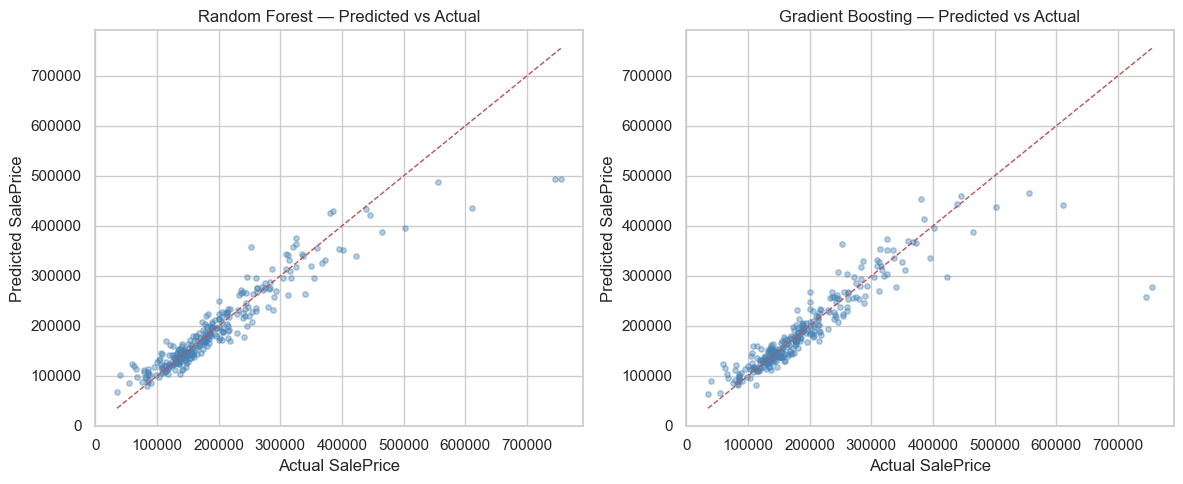

In [26]:
# Visualise: predicted vs actual on validation set for both models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pipeline, name in [
    (axes[0], rf_pipeline, 'Random Forest'),
    (axes[1], gb_pipeline, 'Gradient Boosting'),
]:
    preds = pipeline.predict(X_val)
    ax.scatter(y_val, preds, alpha=0.4, s=15, color='steelblue')
    ax.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=1)
    ax.set_xlabel('Actual SalePrice')
    ax.set_ylabel('Predicted SalePrice')
    ax.set_title(f'{name} — Predicted vs Actual')

plt.tight_layout()
plt.show()

## 6) Pick Best Model

Based on validation RMSE, we pick the better model.  


In [27]:
# Pick based on lowest validation RMSE
if rf_results['val_rmse'] < gb_results['val_rmse']:
    best_pipeline = rf_pipeline
    best_model_name = 'RandomForest'
else:
    best_pipeline = gb_pipeline
    best_model_name = 'GradientBoosting'

print(f'Winner: {best_model_name}')
print()

# Final evaluation on test set
test_preds = best_pipeline.predict(X_test)


test_rmse  = np.sqrt(mean_squared_error(y_test, test_preds))
test_r2    = r2_score(y_test, test_preds)

print('FINAL TEST SET RESULTS:')
print(f'  Test RMSE: ${test_rmse:,.0f}')
print(f'  Test R²:   {test_r2:.3f}')

Winner: RandomForest

FINAL TEST SET RESULTS:
  Test RMSE: $23,181
  Test R²:   0.890


In [28]:
training_stats = {
    'median_price': int(y_train.median()),
    'mean_price':   int(y_train.mean()),
    'min_price':    int(y_train.min()),
    'max_price':    int(y_train.max()),
    'std_price':    int(y_train.std()),
    'p25_price':    int(y_train.quantile(0.25)),
    'p75_price':    int(y_train.quantile(0.75)),
}

print('Training data stats (for Stage 2 LLM context):')
for k, v in training_stats.items():
    print(f'  {k}: ${v:,}')

print()


Training data stats (for Stage 2 LLM context):
  median_price: $164,945
  mean_price: $179,921
  min_price: $34,900
  max_price: $625,000
  std_price: $75,389
  p25_price: $129,000
  p75_price: $213,625



## 7) Serialize the Model



In [29]:
model_path = 'house_price_model.pkl'
joblib.dump(best_pipeline, model_path)

print(f'Model saved to: {model_path}')
print(f'Model type:     {best_model_name}')
print(f'Test RMSE:      ${test_rmse:,.0f}')
print(f'Test R²:        {test_r2:.3f}')
print()


Model saved to: house_price_model.pkl
Model type:     RandomForest
Test RMSE:      $23,181
Test R²:        0.890



In [30]:
# Quick smoke test — load the saved model and run one prediction
loaded_pipeline = joblib.load(model_path)

# Sample input matching our 10 features
sample = pd.DataFrame([{
    'GrLivArea':     1500,
    'GarageCars':    2,
    'TotalBsmtSF':   800,
    'YearBuilt':     2000,
    'FullBath':      2,
    'BedroomAbvGr':  3,
    'LotArea':       9000,
    'OverallQual':   7,
    'OverallCond':   5,
    'Neighborhood':  'CollgCr',
}])

prediction = loaded_pipeline.predict(sample)[0]
print(f'Smoke test prediction: ${prediction:,.0f}')
print('Model loads and predicts correctly.')

Smoke test prediction: $183,601
Model loads and predicts correctly.


In [31]:
# # Download the model in Colab
# from google.colab import files
# files.download('house_price_model.pkl')